# EEE3092F Lab 1 – Amplitude Modulation Pre-lab Simulation

**Covers:**
1. DSB-SC modulation – time domain + FFT  
2. DSB-SC modulation variations (Section 1.1):
   - 2a. Effect of varying modulating frequency
   - 2b. Square wave modulating signal
   - 2c. Square wave carrier signal (wide FFT 0–200 kHz)
   - 2d. dB vs linear FFT scale comparison
3. DSB-SC demodulation (synchronous detection) – time domain + FFT  
4. DSB-LC modulation – time domain + FFT (m < 1, m = 1, m > 1)  
5. DSB-LC demodulation via |signal| + LPF *(post-lab bonus)*  

> **Hardware reference:** 1 kHz modulating signal, 20 kHz carrier, both at 2 V peak (4 Vpp).  
> AD633 multiplier scale factor K = 0.1 (from datasheet: W = (X1−X2)(Y1−Y2)/10).

## 0. Imports and Shared Parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, square

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.4,
})

# ── Simulation parameters ────────────────────────────────────────────────
fs = 500_000           # sample rate (Hz) — well above 2*(fc + fm)
T  = 0.05              # record length (s) → FFT resolution δf = 1/T = 20 Hz
t  = np.arange(0, T, 1/fs)
N  = len(t)

# ── Signal parameters (match lab hardware) ──────────────────────────────
fm = 1_000.0           # modulating frequency  (Hz)
fc = 20_000.0          # carrier frequency     (Hz)
Am = 2.0               # modulating amplitude  (V peak) = 4 Vpp
Ac = 2.0               # carrier amplitude     (V peak) = 4 Vpp
K  = 0.1               # AD633 scale factor

print(f'Sample rate   : {fs:,} Hz')
print(f'Record length : {T*1e3:.0f} ms  ->  FFT resolution delta_f = {1/T:.1f} Hz')
print(f'N = {N:,} samples')

Sample rate   : 500,000 Hz
Record length : 50 ms  ->  FFT resolution delta_f = 20.0 Hz
N = 25,001 samples


## Helper Functions

**`onesided_fft`** mirrors the Keysight DSO-X 2002A FFT display in Vrms mode.  
**`plot_td_fd`** is a convenience function used throughout to plot time domain and
frequency domain side by side.

In [2]:
def onesided_fft(x, fs):
    """
    Returns (freqs_Hz, magnitude_Vrms) for a real signal x sampled at fs.
    Mirrors the Keysight DSO-X 2002A FFT display in Vrms mode.
    """
    n   = len(x)
    X   = np.fft.rfft(x)
    f   = np.fft.rfftfreq(n, d=1/fs)
    mag = np.abs(X) / n
    mag[1:-1] *= 2          # fold negative-frequency energy
    mag /= np.sqrt(2)       # peak -> Vrms
    return f, mag


def plot_td_fd(signals, title, t, fs,
               t_window_ms=5, f_max_khz=50,
               db_scale=True, linear_overlay=False,
               vlines_khz=None):
    """
    Plot one or more signals in time domain (top) and frequency domain (bottom).

    Parameters
    ----------
    signals      : list of (array, label, colour) tuples
    title        : figure title string
    t_window_ms  : how many ms to show in time domain
    f_max_khz    : upper frequency limit for FFT plot
    db_scale     : if True plot FFT in dBVrms; if False plot in Vrms
    linear_overlay: if True, add a second axes showing the linear scale as well
    vlines_khz   : list of frequencies (kHz) to mark with dashed vertical lines
    """
    n_rows = 3 if linear_overlay else 2
    fig, axes = plt.subplots(n_rows, 1, figsize=(10, 4*n_rows))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    t_ms = t * 1e3
    mask = t_ms <= t_window_ms

    # ── Time domain ──────────────────────────────────────────────────────
    for sig, lbl, col in signals:
        axes[0].plot(t_ms[mask], sig[mask], label=lbl, color=col)
    axes[0].set_xlabel('Time (ms)')
    axes[0].set_ylabel('Amplitude (V)')
    axes[0].set_title('Time Domain')
    axes[0].legend()

    # ── Frequency domain (dB) ────────────────────────────────────────────
    for sig, lbl, col in signals:
        f, mag = onesided_fft(sig, fs)
        if db_scale:
            axes[1].plot(f/1e3, 20*np.log10(mag + 1e-12), label=lbl, color=col)
        else:
            axes[1].plot(f/1e3, mag * 1e3, label=lbl, color=col)  # mVrms

    if vlines_khz:
        for vf in vlines_khz:
            axes[1].axvline(vf, color='black', linestyle='--', lw=1, alpha=0.6)

    axes[1].set_xlim(0, f_max_khz)
    if db_scale:
        axes[1].set_ylim(-80, 10)
        axes[1].set_ylabel('Magnitude (dBVrms)')
    else:
        axes[1].set_ylabel('Magnitude (mVrms)')
    axes[1].set_xlabel('Frequency (kHz)')
    axes[1].set_title('Frequency Spectrum — dB scale' if db_scale else 'Frequency Spectrum — Linear scale')
    axes[1].legend()

    # ── Optional linear overlay ──────────────────────────────────────────
    if linear_overlay:
        for sig, lbl, col in signals:
            f, mag = onesided_fft(sig, fs)
            axes[2].plot(f/1e3, mag * 1e3, label=lbl, color=col)
        if vlines_khz:
            for vf in vlines_khz:
                axes[2].axvline(vf, color='black', linestyle='--', lw=1, alpha=0.6)
        axes[2].set_xlim(0, f_max_khz)
        axes[2].set_xlabel('Frequency (kHz)')
        axes[2].set_ylabel('Magnitude (mVrms)')
        axes[2].set_title('Frequency Spectrum — Linear scale (for comparison)')
        axes[2].legend()

    plt.tight_layout()
    return fig

## 1. DSB-SC Modulation — Baseline (Sine / Sine)

$$\phi(t) = K \cdot x(t) \cdot c(t) = K \cdot A_m\cos(\omega_m t)\cdot A_c\cos(\omega_c t)$$

Expanding via trig identity:
$$\phi(t) = \frac{K A_m A_c}{2}\left[\cos((\omega_c+\omega_m)t) + \cos((\omega_c-\omega_m)t)\right]$$

**Expected spectrum:** two lines only — LSB at 19 kHz and USB at 21 kHz.  
No component at the carrier frequency fc = 20 kHz (carrier is suppressed).

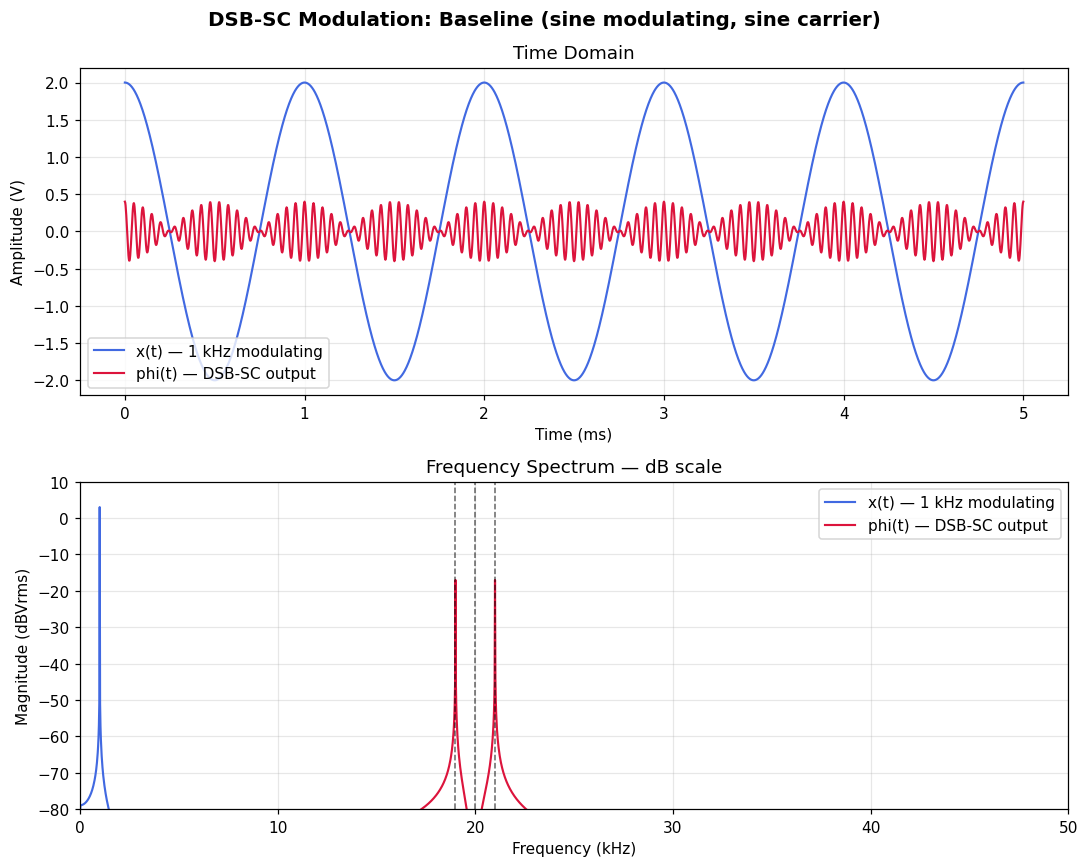

Saved  01_DSBSC_baseline.png


In [3]:
x_t       = Am * np.cos(2*np.pi*fm*t)    # 1 kHz sine modulating signal
c_t       = Ac * np.cos(2*np.pi*fc*t)    # 20 kHz sine carrier
phi_DSBSC = K  * x_t * c_t

fig = plot_td_fd(
    signals=[
        (x_t,       'x(t) — 1 kHz modulating', 'royalblue'),
        (phi_DSBSC, 'phi(t) — DSB-SC output',  'crimson'),
    ],
    title='DSB-SC Modulation: Baseline (sine modulating, sine carrier)',
    t=t, fs=fs,
    vlines_khz=[(fc-fm)/1e3, fc/1e3, (fc+fm)/1e3]
)
fig.savefig('01_DSBSC_baseline.png', bbox_inches='tight')
plt.show()
print('Saved  01_DSBSC_baseline.png')

## 2a. Variation: Effect of Changing the Modulating Frequency

From Section 1.1: *"Try varying the frequency of the modulating signal. What effect does this have on the spectrum?"*

**Expected:** The sidebands move closer to or further from fc.  
- Lower fm → sidebands closer together (LSB and USB closer to 20 kHz)  
- Higher fm → sidebands spread further apart  
The carrier remains suppressed regardless of fm.

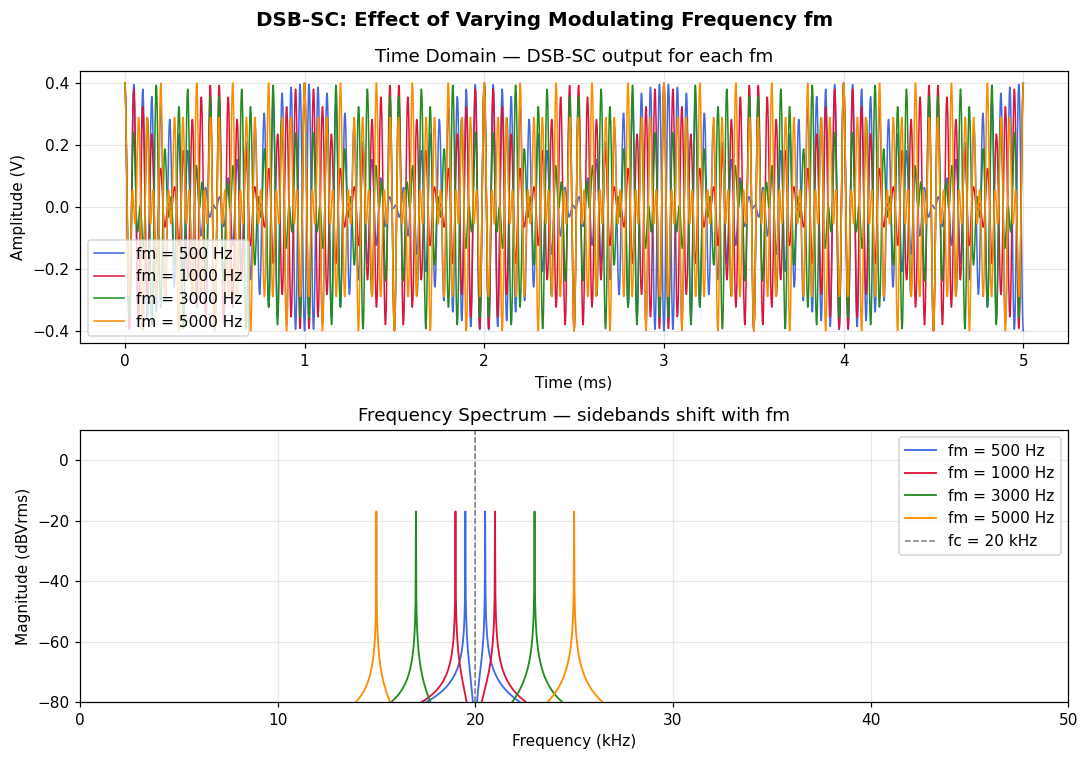

Saved  02a_vary_fm.png


In [4]:
fm_values  = [500, 1000, 3000, 5000]   # Hz
colours    = ['royalblue', 'crimson', 'forestgreen', 'darkorange']

fig, axes = plt.subplots(2, 1, figsize=(10, 7))
fig.suptitle('DSB-SC: Effect of Varying Modulating Frequency fm', fontsize=13, fontweight='bold')

t_ms = t * 1e3
mask = t_ms <= 5

for fm_i, col in zip(fm_values, colours):
    x_i   = Am * np.cos(2*np.pi*fm_i*t)
    phi_i = K  * x_i * c_t
    label = f'fm = {fm_i} Hz'

    # Time domain — show only the DSB-SC output (modulating waves would clutter)
    axes[0].plot(t_ms[mask], phi_i[mask], label=label, color=col, lw=1.0)

    # Frequency domain
    f_i, m_i = onesided_fft(phi_i, fs)
    axes[1].plot(f_i/1e3, 20*np.log10(m_i + 1e-12), label=label, color=col, lw=1.2)

# Mark carrier frequency
for ax in axes:
    if ax == axes[1]:
        ax.axvline(fc/1e3, color='black', linestyle='--', lw=1, alpha=0.5, label='fc = 20 kHz')

axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Amplitude (V)')
axes[0].set_title('Time Domain — DSB-SC output for each fm')
axes[0].legend()

axes[1].set_xlim(0, 50)
axes[1].set_ylim(-80, 10)
axes[1].set_xlabel('Frequency (kHz)')
axes[1].set_ylabel('Magnitude (dBVrms)')
axes[1].set_title('Frequency Spectrum — sidebands shift with fm')
axes[1].legend()

plt.tight_layout()
fig.savefig('02a_vary_fm.png', bbox_inches='tight')
plt.show()
print('Saved  02a_vary_fm.png')

## 2b. Variation: Square Wave as the Modulating Signal

From Section 1.1: *"Try using a square wave as the modulating signal x(t). Examine the spectrum of x(t) and φ(t)."*

**Why this is interesting:** A square wave contains a fundamental at fm plus all odd harmonics
(fm, 3fm, 5fm, 7fm, ...) with amplitudes 1, 1/3, 1/5, 1/7, ...  
Each harmonic independently modulates the carrier, so the DSB-SC output
has sideband *pairs* around fc for every harmonic:

| Harmonic | LSB | USB |
|----------|-----|-----|
| 1st (1 kHz) | 19 kHz | 21 kHz |
| 3rd (3 kHz) | 17 kHz | 23 kHz |
| 5th (5 kHz) | 15 kHz | 25 kHz |
| 7th (7 kHz) | 13 kHz | 27 kHz |
| ... | ... | ... |

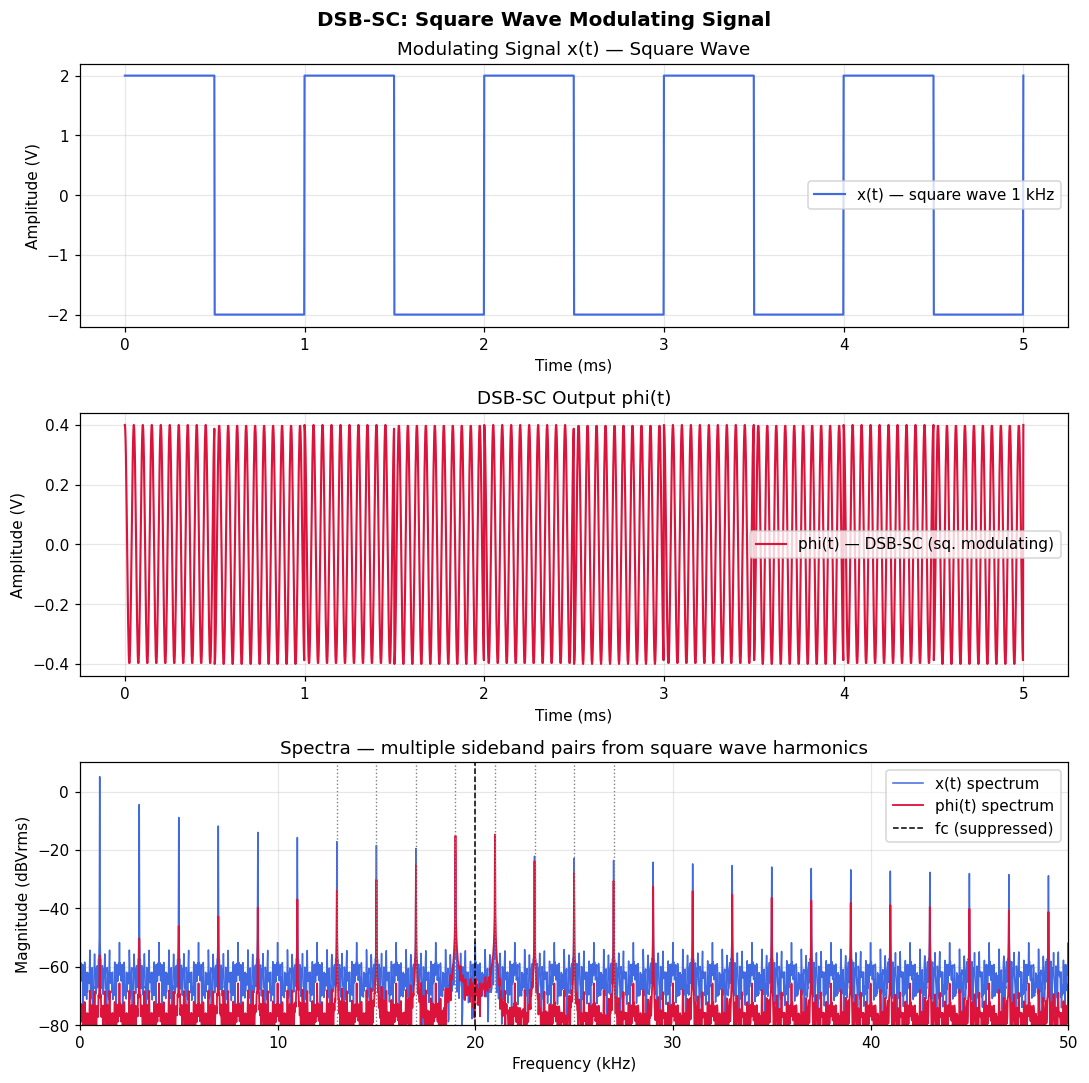

Saved  02b_square_modulating.png


In [5]:
# scipy.signal.square generates a square wave in the range [-1, +1]
x_sq      = Am * square(2*np.pi*fm*t)    # 1 kHz square wave, amplitude Am
phi_sq    = K  * x_sq * c_t             # DSB-SC with square modulating wave

fig, axes = plt.subplots(3, 1, figsize=(10, 10))
fig.suptitle('DSB-SC: Square Wave Modulating Signal', fontsize=13, fontweight='bold')

t_ms = t * 1e3
mask = t_ms <= 5

# Time domain — modulating signal
axes[0].plot(t_ms[mask], x_sq[mask],   label='x(t) — square wave 1 kHz', color='royalblue')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Amplitude (V)')
axes[0].set_title('Modulating Signal x(t) — Square Wave')
axes[0].legend()

# Time domain — DSB-SC output
axes[1].plot(t_ms[mask], phi_sq[mask], label='phi(t) — DSB-SC (sq. modulating)', color='crimson')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Amplitude (V)')
axes[1].set_title('DSB-SC Output phi(t)')
axes[1].legend()

# Frequency domain — both signals overlaid
f_x,  m_x  = onesided_fft(x_sq,   fs)
f_ph, m_ph = onesided_fft(phi_sq,  fs)
axes[2].plot(f_x /1e3, 20*np.log10(m_x  + 1e-12), label='x(t) spectrum',   color='royalblue', lw=1.0)
axes[2].plot(f_ph/1e3, 20*np.log10(m_ph + 1e-12), label='phi(t) spectrum', color='crimson',   lw=1.2)

# Mark expected harmonic sidebands
for h in [1, 3, 5, 7]:
    axes[2].axvline((fc - h*fm)/1e3, color='gray',  linestyle=':', lw=0.9)
    axes[2].axvline((fc + h*fm)/1e3, color='gray',  linestyle=':', lw=0.9)
axes[2].axvline(fc/1e3, color='black', linestyle='--', lw=1, label='fc (suppressed)')

axes[2].set_xlim(0, 50)
axes[2].set_ylim(-80, 10)
axes[2].set_xlabel('Frequency (kHz)')
axes[2].set_ylabel('Magnitude (dBVrms)')
axes[2].set_title('Spectra — multiple sideband pairs from square wave harmonics')
axes[2].legend()

plt.tight_layout()
fig.savefig('02b_square_modulating.png', bbox_inches='tight')
plt.show()
print('Saved  02b_square_modulating.png')

## 2c. Variation: Square Wave as the Carrier Signal

From Section 1.1: *"Try using a square wave as the carrier signal. Examine the spectrum of φ(t) over a wide bandwidth 0–200 kHz."*

**Why this is interesting:** A square wave carrier at fc contains odd harmonics at fc, 3fc, 5fc, ...  
Each harmonic acts as its own carrier, producing sideband pairs around every harmonic:

| Carrier harmonic | LSB | USB | Relative amplitude |
|-----------------|-----|-----|--------------------|
| 1×fc = 20 kHz   | 19 kHz | 21 kHz | 1 |
| 3×fc = 60 kHz   | 59 kHz | 61 kHz | 1/3 |
| 5×fc = 100 kHz  | 99 kHz | 101 kHz | 1/5 |
| 7×fc = 140 kHz  | 139 kHz | 141 kHz | 1/7 |

This is why a **wide FFT span of 0–200 kHz** is needed to see all the harmonic sidebands.

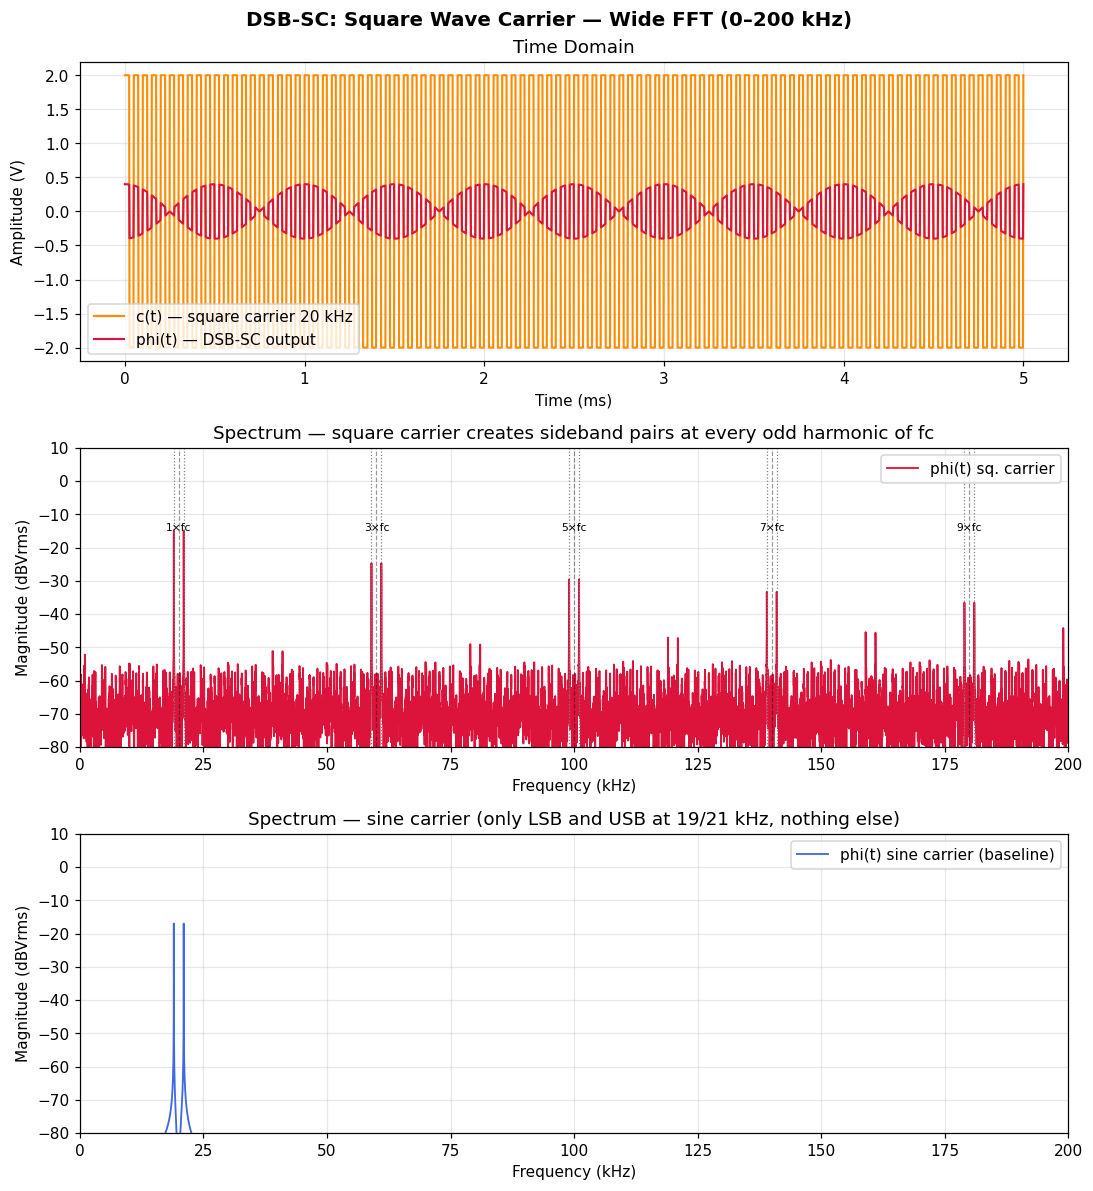

Saved  02c_square_carrier_wide_fft.png


In [6]:
# Restore sine modulating signal
x_t    = Am * np.cos(2*np.pi*fm*t)

# Square wave carrier
c_sq   = Ac * square(2*np.pi*fc*t)    # 20 kHz square carrier
phi_sq_carrier = K * x_t * c_sq

# Also compute sine-carrier baseline for comparison
c_t       = Ac * np.cos(2*np.pi*fc*t)
phi_DSBSC = K  * x_t * c_t

fig, axes = plt.subplots(3, 1, figsize=(10, 11))
fig.suptitle('DSB-SC: Square Wave Carrier — Wide FFT (0–200 kHz)', fontsize=13, fontweight='bold')

# Time domain — square carrier
mask5 = (t * 1e3) <= 5
axes[0].plot(t[mask5]*1e3, c_sq[mask5],          label='c(t) — square carrier 20 kHz', color='darkorange')
axes[0].plot(t[mask5]*1e3, phi_sq_carrier[mask5], label='phi(t) — DSB-SC output',       color='crimson')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Amplitude (V)')
axes[0].set_title('Time Domain')
axes[0].legend()

# Frequency domain — square carrier  (WIDE: 0-200 kHz)
f_sq, m_sq   = onesided_fft(phi_sq_carrier, fs)
axes[1].plot(f_sq/1e3, 20*np.log10(m_sq + 1e-12), color='crimson', lw=1.2, label='phi(t) sq. carrier')

# Mark harmonic sideband pairs
for h in [1, 3, 5, 7, 9]:
    f_center = h * fc
    if f_center + fm <= fs/2:
        axes[1].axvline((f_center - fm)/1e3, color='gray', linestyle=':', lw=0.8)
        axes[1].axvline((f_center + fm)/1e3, color='gray', linestyle=':', lw=0.8)
        axes[1].axvline( f_center/1e3,       color='black', linestyle='--', lw=0.8, alpha=0.4)
        axes[1].annotate(f'{h}×fc', xy=(f_center/1e3, -15), fontsize=7,
                         ha='center', color='black')

axes[1].set_xlim(0, 200)
axes[1].set_ylim(-80, 10)
axes[1].set_xlabel('Frequency (kHz)')
axes[1].set_ylabel('Magnitude (dBVrms)')
axes[1].set_title('Spectrum — square carrier creates sideband pairs at every odd harmonic of fc')
axes[1].legend()

# Frequency domain — sine carrier for comparison (same wide span)
f_si, m_si = onesided_fft(phi_DSBSC, fs)
axes[2].plot(f_si/1e3, 20*np.log10(m_si + 1e-12), color='royalblue', lw=1.2, label='phi(t) sine carrier (baseline)')
axes[2].set_xlim(0, 200)
axes[2].set_ylim(-80, 10)
axes[2].set_xlabel('Frequency (kHz)')
axes[2].set_ylabel('Magnitude (dBVrms)')
axes[2].set_title('Spectrum — sine carrier (only LSB and USB at 19/21 kHz, nothing else)')
axes[2].legend()

plt.tight_layout()
fig.savefig('02c_square_carrier_wide_fft.png', bbox_inches='tight')
plt.show()
print('Saved  02c_square_carrier_wide_fft.png')

## 2d. Variation: dB Scale vs Linear Scale FFT Comparison

From Section 1.1: *"Include at least one example showing and comparing the FFT displayed with a dB scale versus a linear scale."*

**Key differences:**
- **dB scale** compresses the range so weak components (harmonics, noise floor) that are invisible on a linear scale become visible. It reveals the *dynamic range* of the signal.
- **Linear scale** makes it easier to see the *relative amplitudes* of dominant components, but weak components disappear into the baseline.

The dB scale is generally preferred in the lab (as the document notes) because it shows all components clearly.

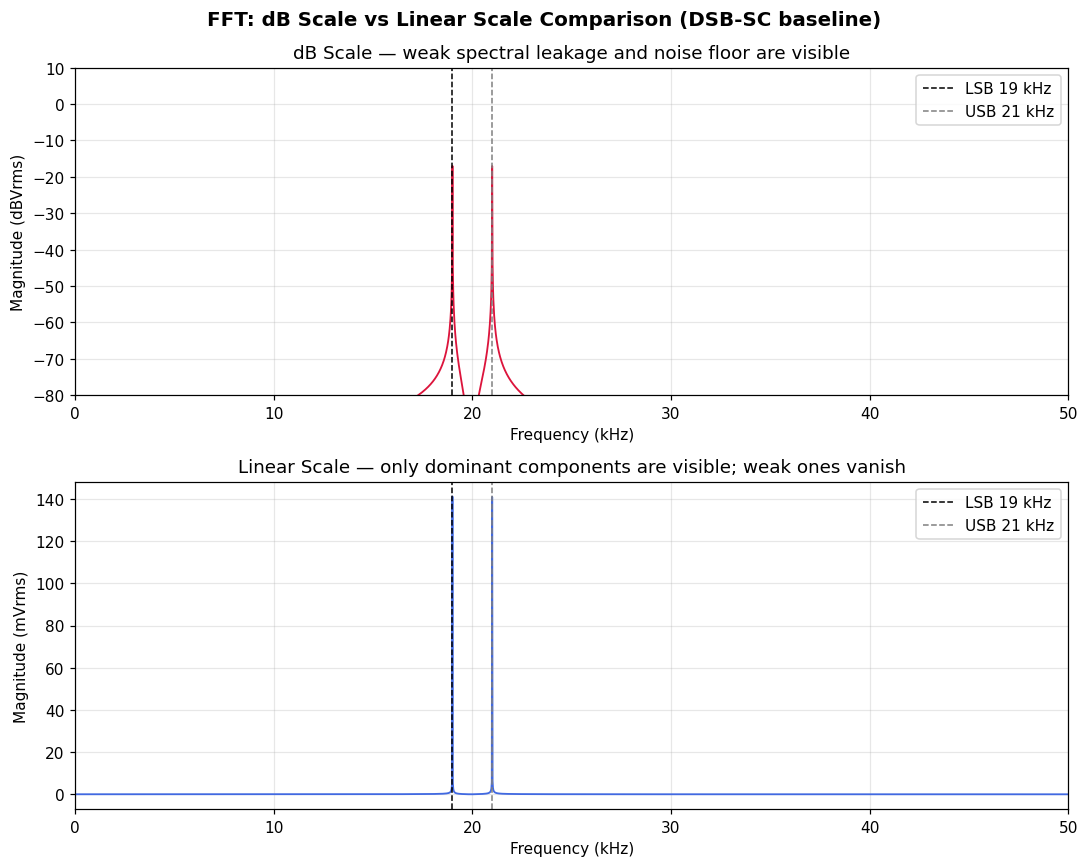

Saved  02d_db_vs_linear.png
LSB amplitude: 141.2 mVrms
USB amplitude: 141.0 mVrms


In [7]:
# Use the baseline DSB-SC signal (sine modulating, sine carrier)
# c_t and phi_DSBSC already defined above

f_db, m_db = onesided_fft(phi_DSBSC, fs)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
fig.suptitle('FFT: dB Scale vs Linear Scale Comparison (DSB-SC baseline)',
             fontsize=13, fontweight='bold')

# dB scale
axes[0].plot(f_db/1e3, 20*np.log10(m_db + 1e-12), color='crimson', lw=1.2)
axes[0].axvline((fc-fm)/1e3, color='black', linestyle='--', lw=1, label='LSB 19 kHz')
axes[0].axvline((fc+fm)/1e3, color='gray',  linestyle='--', lw=1, label='USB 21 kHz')
axes[0].set_xlim(0, 50)
axes[0].set_ylim(-80, 10)
axes[0].set_xlabel('Frequency (kHz)')
axes[0].set_ylabel('Magnitude (dBVrms)')
axes[0].set_title('dB Scale — weak spectral leakage and noise floor are visible')
axes[0].legend()

# Linear scale (mVrms)
axes[1].plot(f_db/1e3, m_db * 1e3, color='royalblue', lw=1.2)
axes[1].axvline((fc-fm)/1e3, color='black', linestyle='--', lw=1, label='LSB 19 kHz')
axes[1].axvline((fc+fm)/1e3, color='gray',  linestyle='--', lw=1, label='USB 21 kHz')
axes[1].set_xlim(0, 50)
axes[1].set_xlabel('Frequency (kHz)')
axes[1].set_ylabel('Magnitude (mVrms)')
axes[1].set_title('Linear Scale — only dominant components are visible; weak ones vanish')
axes[1].legend()

plt.tight_layout()
fig.savefig('02d_db_vs_linear.png', bbox_inches='tight')
plt.show()
print('Saved  02d_db_vs_linear.png')
print(f'LSB amplitude: {m_db[np.argmin(np.abs(f_db-(fc-fm)))] * 1e3:.1f} mVrms')
print(f'USB amplitude: {m_db[np.argmin(np.abs(f_db-(fc+fm)))] * 1e3:.1f} mVrms')

## 3. DSB-SC Demodulation (Synchronous Detection)

Multiply φ(t) by the same carrier (second AD633), then low-pass filter:

$$K\cdot\phi(t)\cdot c(t) = \frac{K^2 A_m A_c}{2}\cos(\omega_m t) + \underbrace{\frac{K^2 A_m A_c}{4}[\cos((2\omega_c+\omega_m)t)+\cos((2\omega_c-\omega_m)t)]}_{\text{removed by LPF}}$$

**LPF:** R = 1 kΩ (on-board) + C = 100 nF → f₃dB ≈ 1.6 kHz

RC LPF  f3dB = 1592 Hz
Expected demodulated amplitude at f3dB ~ 7.1 mV


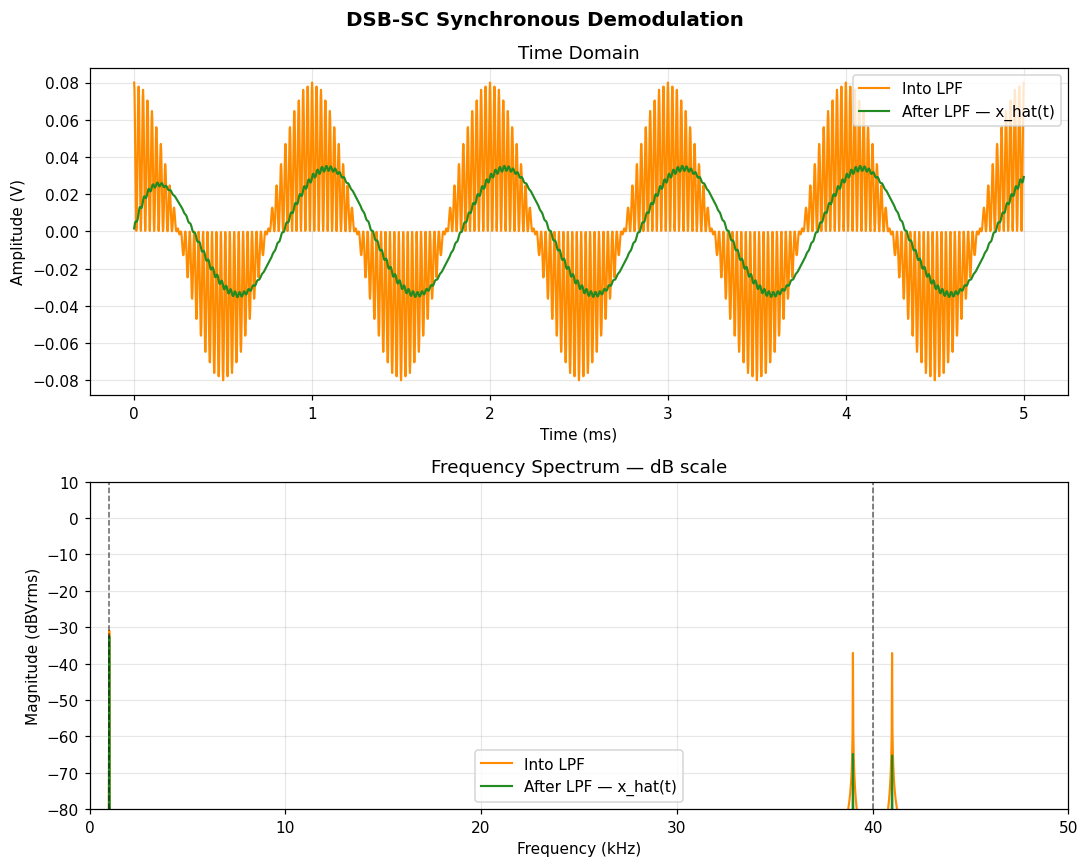

Saved  03_DSBSC_demodulation.png


In [8]:
# Restore baseline signals
x_t       = Am * np.cos(2*np.pi*fm*t)
c_t       = Ac * np.cos(2*np.pi*fc*t)
phi_DSBSC = K  * x_t * c_t

# Second AD633 multiplication
demod_raw = K * phi_DSBSC * c_t

# 1st-order RC LPF  (R = 1 kΩ on-board, C = 100 nF)
R_lpf = 1_000.0
C_lpf = 100e-9
f3dB  = 1 / (2*np.pi*R_lpf*C_lpf)
alpha = np.exp(-1.0 / (R_lpf * C_lpf * fs))
b_lpf = [1 - alpha]
a_lpf = [1, -alpha]
demod_lpf = lfilter(b_lpf, a_lpf, demod_raw)

exp_mV = Am * K**2 * 0.5 * 0.707 * 1e3
print(f'RC LPF  f3dB = {f3dB:.0f} Hz')
print(f'Expected demodulated amplitude at f3dB ~ {exp_mV:.1f} mV')

fig = plot_td_fd(
    signals=[
        (demod_raw, 'Into LPF',            'darkorange'),
        (demod_lpf, 'After LPF — x_hat(t)', 'forestgreen'),
    ],
    title='DSB-SC Synchronous Demodulation',
    t=t, fs=fs,
    vlines_khz=[fm/1e3, 2*fc/1e3]
)
fig.savefig('03_DSBSC_demodulation.png', bbox_inches='tight')
plt.show()
print('Saved  03_DSBSC_demodulation.png')

## 4. DSB-LC Modulation (m < 1, m = 1, m > 1)

$$\phi_{LC}(t) = K\cdot[x(t)+A]\cdot\cos(\omega_c t), \quad m = \frac{A_m}{A}$$

The DC offset A is controlled by the potentiometer on the DSB-LC module (pin 2 of AD633).  
**At m > 1** the envelope crosses zero, causing phase reversals — this is over-modulation.

In [9]:
cases = [
    (0.5, 'm=0.5  (under-modulated)',   'steelblue'),
    (1.0, 'm=1.0  (maximum modulation)', 'darkorange'),
    (1.5, 'm=1.5  (over-modulated)',     'crimson'),
]

fig_t, axes_t = plt.subplots(3, 1, figsize=(10, 10))
fig_t.suptitle('DSB-LC Modulation — Time Domain', fontsize=13, fontweight='bold')

fig_f, axes_f = plt.subplots(3, 1, figsize=(10, 10))
fig_f.suptitle('DSB-LC Modulation — Frequency Spectra', fontsize=13, fontweight='bold')

t_ms = t * 1e3
mask = t_ms <= 5

for i, (m, label, col) in enumerate(cases):
    A      = Am / m
    phi_lc = K * (x_t + A) * c_t

    axes_t[i].plot(t_ms[mask], phi_lc[mask], color=col, lw=1.0)
    axes_t[i].set_title(label)
    axes_t[i].set_xlabel('Time (ms)')
    axes_t[i].set_ylabel('Amplitude (V)')

    fl, ml = onesided_fft(phi_lc, fs)
    axes_f[i].plot(fl/1e3, 20*np.log10(ml + 1e-12), color=col, lw=1.2)
    axes_f[i].axvline(fc/1e3,         color='black', linestyle='--', lw=1, label='fc = 20 kHz')
    axes_f[i].axvline((fc-fm)/1e3,    color='gray',  linestyle=':',  lw=1, label='LSB = 19 kHz')
    axes_f[i].axvline((fc+fm)/1e3,    color='gray',  linestyle='-.', lw=1, label='USB = 21 kHz')
    axes_f[i].set_xlim(0, 50)
    axes_f[i].set_ylim(-80, 10)
    axes_f[i].set_title(label)
    axes_f[i].set_xlabel('Frequency (kHz)')
    axes_f[i].set_ylabel('Magnitude (dBVrms)')
    axes_f[i].legend(fontsize=8)

fig_t.tight_layout()
fig_t.savefig('04_DSBLC_time.png', bbox_inches='tight')
fig_t.show()

fig_f.tight_layout()
fig_f.savefig('04_DSBLC_freq.png', bbox_inches='tight')
fig_f.show()

print('Saved  04_DSBLC_time.png  and  04_DSBLC_freq.png')

C:\Users\Student\AppData\Local\Temp\ipykernel_5204\2837580009.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_t.show()


Saved  04_DSBLC_time.png  and  04_DSBLC_freq.png


C:\Users\Student\AppData\Local\Temp\ipykernel_5204\2837580009.py:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_f.show()


## 5. DSB-LC Demodulation via |signal| + LPF *(post-lab bonus)*

From the lab document: *"take the magnitude of the DSB-LC signal (equivalent to full wave rectification) and then pass it through a LPF."*

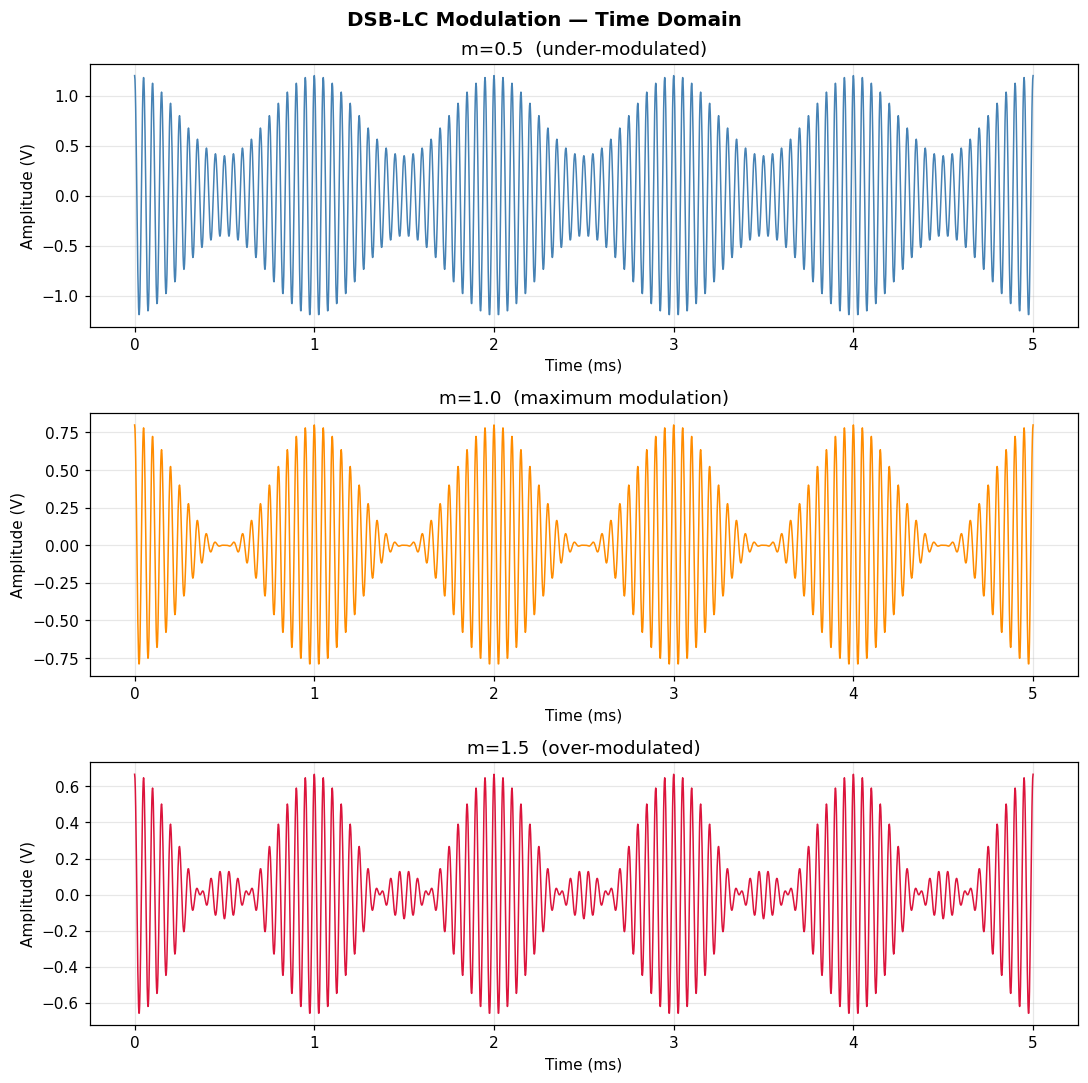

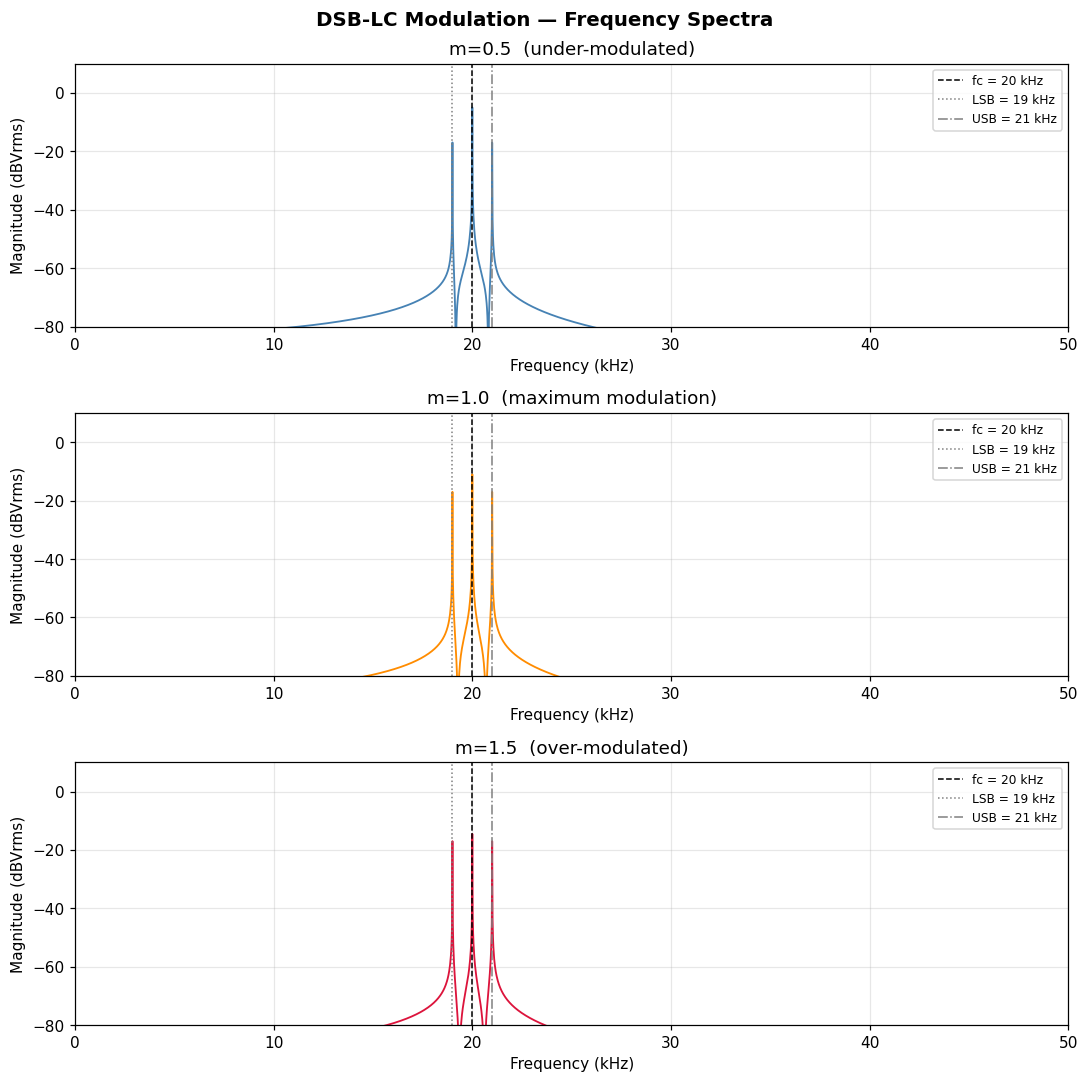

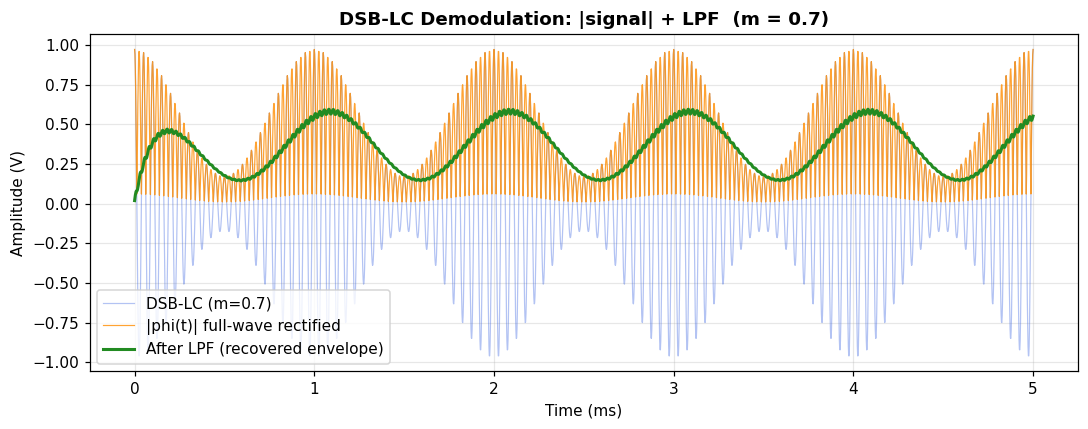

Saved  05_DSBLC_demodulation.png


In [10]:
m_demo   = 0.7
phi_demo = K * (x_t + Am/m_demo) * c_t

rectified = np.abs(phi_demo)
demod_env = lfilter(b_lpf, a_lpf, rectified)

fig, ax = plt.subplots(figsize=(10, 4))
t_ms = t * 1e3
mask = t_ms <= 5
ax.plot(t_ms[mask], phi_demo[mask],  color='royalblue',  lw=0.8, alpha=0.4, label='DSB-LC (m=0.7)')
ax.plot(t_ms[mask], rectified[mask], color='darkorange',  lw=0.8, alpha=0.8, label='|phi(t)| full-wave rectified')
ax.plot(t_ms[mask], demod_env[mask], color='forestgreen', lw=2.0,            label='After LPF (recovered envelope)')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude (V)')
ax.set_title('DSB-LC Demodulation: |signal| + LPF  (m = 0.7)', fontweight='bold')
ax.legend()
plt.tight_layout()
fig.savefig('05_DSBLC_demodulation.png', bbox_inches='tight')
plt.show()
print('Saved  05_DSBLC_demodulation.png')

## Summary of Output Figures

| Figure | Section | Content |
|--------|---------|-------------------------------------------|
| `01_DSBSC_baseline.png`         | 1   | DSB-SC sine/sine — time + FFT |
| `02a_vary_fm.png`               | 2a  | Effect of varying fm |
| `02b_square_modulating.png`     | 2b  | Square wave modulating signal |
| `02c_square_carrier_wide_fft.png` | 2c | Square wave carrier — wide 0–200 kHz FFT |
| `02d_db_vs_linear.png`          | 2d  | dB scale vs linear scale comparison |
| `03_DSBSC_demodulation.png`     | 3   | Synchronous demodulation |
| `04_DSBLC_time.png`             | 4   | DSB-LC time domain (m=0.5, 1.0, 1.5) |
| `04_DSBLC_freq.png`             | 4   | DSB-LC frequency spectra |
| `05_DSBLC_demodulation.png`     | 5   | Envelope demodulation via |signal| + LPF |
